In [62]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    TimeSeriesSplit
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import joblib

In [63]:
df = pd.read_csv("../data/processed_stock_data.csv")

df.head()

,Date,Unnamed: 0,Close,High,Low,Open,Volume,Returns,MA20,MA50,...,return_lag_5,rolling_mean_10,rolling_mean_30,momentum_5,momentum_10,momentum_30,day_of_week,month,quarter,target
0,2010-03-16,49,86.877113,86.959201,86.190510,86.429327,168673000,0.007966,84.156820,83.279019,...,0.001662,85.503896,82.955024,0.017037,0.037523,0.067394,1,3,1,1
1,2010-03-17,50,87.392036,87.675635,86.884550,87.138296,177468100,0.005927,84.412056,83.335290,...,0.004456,85.862122,83.122196,0.018526,0.042743,0.060881,2,3,1,0
2,2010-03-18,51,87.347275,87.518921,86.996512,87.399516,196509100,-0.000512,84.640797,83.386189,...,0.004175,86.190495,83.301558,0.013773,0.039062,0.065647,3,3,1,0
3,2010-03-19,52,86.905121,87.894297,86.567898,86.905121,226641100,-0.005062,84.838849,83.427050,...,0.000087,86.354500,83.550513,0.008553,0.019235,0.094021,4,3,1,1
4,2010-03-22,53,87.369728,87.527102,86.358072,86.410528,184477800,0.005346,85.059385,83.470038,...,0.000260,86.563472,83.809483,0.013681,0.024504,0.097601,0,3,1,1


In [64]:
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,Date,Close,High,Low,Open,Volume,Returns,MA20,MA50,Volatility,...,return_lag_5,rolling_mean_10,rolling_mean_30,momentum_5,momentum_10,momentum_30,day_of_week,month,quarter,target
0,2010-03-16,86.877113,86.959201,86.190510,86.429327,168673000,0.007966,84.156820,83.279019,0.005395,...,0.001662,85.503896,82.955024,0.017037,0.037523,0.067394,1,3,1,1
1,2010-03-17,87.392036,87.675635,86.884550,87.138296,177468100,0.005927,84.412056,83.335290,0.005422,...,0.004456,85.862122,83.122196,0.018526,0.042743,0.060881,2,3,1,0
2,2010-03-18,87.347275,87.518921,86.996512,87.399516,196509100,-0.000512,84.640797,83.386189,0.005433,...,0.004175,86.190495,83.301558,0.013773,0.039062,0.065647,3,3,1,0
3,2010-03-19,86.905121,87.894297,86.567898,86.905121,226641100,-0.005062,84.838849,83.427050,0.005704,...,0.000087,86.354500,83.550513,0.008553,0.019235,0.094021,4,3,1,1
4,2010-03-22,87.369728,87.527102,86.358072,86.410528,184477800,0.005346,85.059385,83.470038,0.005718,...,0.000260,86.563472,83.809483,0.013681,0.024504,0.097601,0,3,1,1


In [ ]:
future_return = (df["Close"].shift(-5) - df["Close"]) / df["Close"]

df["target"] = (future_return > 0).astype(int)

In [66]:
df.dropna(inplace=True)

df.tail()

,Date,Close,High,Low,Open,Volume,Returns,MA20,MA50,Volatility,...,return_lag_5,rolling_mean_10,rolling_mean_30,momentum_5,momentum_10,momentum_30,day_of_week,month,quarter,target
3720,2024-12-24,591.179077,591.218442,585.447189,586.027285,33160100,0.011115,589.479968,580.186833,0.008789,...,-0.004120,587.198578,586.636794,-0.001599,0.000869,0.007622,1,12,4,0
3721,2024-12-26,591.218445,592.339211,588.013307,589.409389,41219100,0.000067,589.612930,580.649017,0.008719,...,-0.029803,586.797205,586.847921,0.029140,-0.006743,0.010829,3,12,4,0
3722,2024-12-27,584.995056,587.718452,580.816590,587.482441,64969300,-0.010526,589.523898,580.937349,0.009024,...,-0.000307,586.080200,586.842128,0.018619,-0.012108,-0.000297,4,12,4,0
3723,2024-12-30,578.319214,581.779985,574.573345,577.994812,56578800,-0.011412,588.918817,581.091183,0.009232,...,0.012011,584.707367,586.739231,-0.004957,-0.023188,-0.005309,0,12,4,0
3724,2024-12-31,576.215332,580.698577,574.583239,579.980824,57052700,-0.003638,588.155624,581.159041,0.009225,...,0.005988,582.871356,586.814441,-0.014478,-0.030879,0.003931,1,12,4,0


In [67]:
X = df.drop(columns=["target"])

# Remove Date column if present
if "Date" in X.columns:
    X = X.drop(columns=["Date"])

y = df["target"]

print(X.shape)
print(y.shape)

(3725, 41)
(3725,)


In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [69]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [70]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "XGBoost":
        XGBClassifier(
            random_state=42,
            eval_metric="logloss"
        )
}

results = []

for name, model in models.items():

    if name == "Logistic Regression":

        model.fit(X_train_scaled, y_train)

        preds = model.predict(X_test_scaled)

        probs = model.predict_proba(X_test_scaled)[:,1]

    else:

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        probs = model.predict_proba(X_test)[:,1]

    results.append([
        name,
        accuracy_score(y_test,preds),
        precision_score(y_test,preds),
        recall_score(y_test,preds),
        f1_score(y_test,preds),
        roc_auc_score(y_test,probs)
    ])

baseline_results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
)

baseline_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.598658,0.599459,0.993274,0.747679,0.493708
1,Decision Tree,0.523490,0.620690,0.524664,0.568651,0.523201
2,Random Forest,0.497987,0.595745,0.502242,0.545012,0.498695
3,XGBoost,0.531544,0.627968,0.533632,0.576970,0.546125


In [71]:
tscv = TimeSeriesSplit(n_splits=5)

In [72]:
param_grid_lr = {

    "C":[0.01,0.1,1,10,100],
    "penalty":["l2"],
    "solver":["lbfgs"]
}

grid_lr = GridSearchCV(

    LogisticRegression(max_iter=1000),

    param_grid_lr,

    cv=tscv,

    scoring="f1",

    n_jobs=-1

)

grid_lr.fit(X_train_scaled,y_train)

print(grid_lr.best_params_)

{'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


In [73]:
param_grid_dt = {

    "max_depth":[3,5,7,10,None],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]

}

grid_dt = GridSearchCV(

    DecisionTreeClassifier(random_state=42),

    param_grid_dt,

    cv=tscv,

    scoring="f1",

    n_jobs=-1

)

grid_dt.fit(X_train,y_train)

print(grid_dt.best_params_)

{'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [74]:
param_grid_rf = {

    "n_estimators":[100,200,300],

    "max_depth":[5,10,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid_rf = GridSearchCV(

    RandomForestClassifier(random_state=42),

    param_grid_rf,

    cv=tscv,

    scoring="f1",

    n_jobs=-1

)

grid_rf.fit(X_train,y_train)

print(grid_rf.best_params_)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [75]:
param_grid_xgb = {

    "n_estimators":[100,200],

    "max_depth":[3,5,7],

    "learning_rate":[0.01,0.05,0.1],

    "subsample":[0.8,1.0],

    "colsample_bytree":[0.8,1.0]

}

grid_xgb = GridSearchCV(

    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),

    param_grid_xgb,

    cv=tscv,

    scoring="f1",

    n_jobs=-1

)

grid_xgb.fit(X_train,y_train)

print(grid_xgb.best_params_)

{'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}


In [84]:
best_models = {

    "Logistic Regression":grid_lr.best_estimator_,

    "Decision Tree":grid_dt.best_estimator_,

    "Random Forest":grid_rf.best_estimator_,

    "XGBoost":grid_xgb.best_estimator_
}

results=[]

for name,model in best_models.items():

    if name=="Logistic Regression":

        preds=model.predict(X_test_scaled)

        probs=model.predict_proba(X_test_scaled)[:,1]

    else:

        preds=model.predict(X_test)

        probs=model.predict_proba(X_test)[:,1]

    results.append([

        name,

        accuracy_score(y_test,preds),

        precision_score(y_test,preds),

        recall_score(y_test,preds),

        f1_score(y_test,preds),

        roc_auc_score(y_test,probs)

    ])

results_df = pd.DataFrame(results,columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC"
])
results_df.to_csv("../results/DAY4/model_optimization_results.csv", index=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.598658,0.598658,1.000000,0.748950,0.525616
1,Decision Tree,0.522148,0.620968,0.517937,0.564792,0.496194
2,Random Forest,0.481879,0.575000,0.515695,0.543735,0.486502
3,XGBoost,0.499329,0.586288,0.556054,0.570771,0.523246


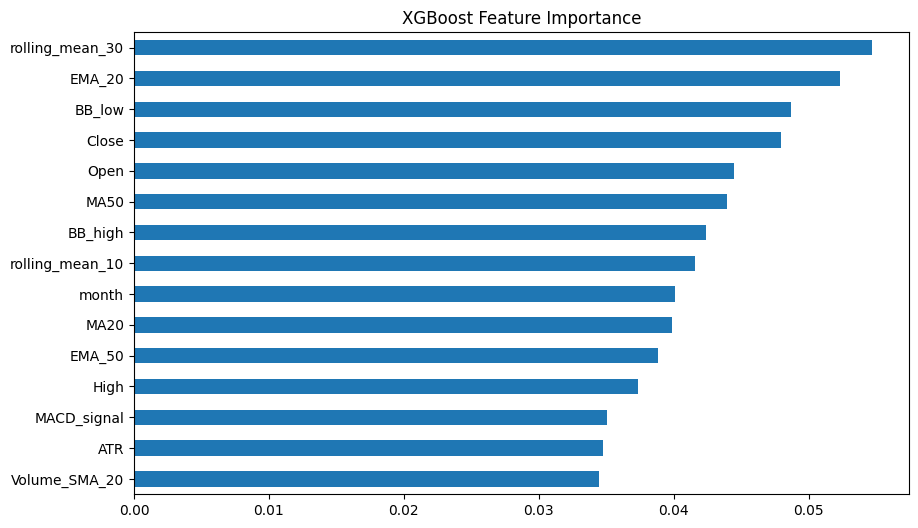

In [77]:
importance = pd.Series(

    grid_xgb.best_estimator_.feature_importances_,

    index=X.columns

).sort_values()

plt.figure(figsize=(10,6))

importance.tail(15).plot(kind="barh")

plt.title("XGBoost Feature Importance")

plt.show()

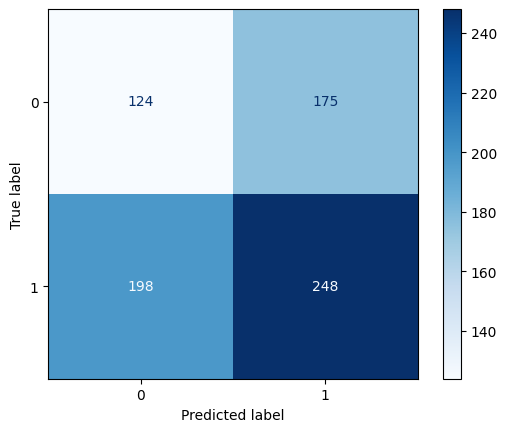

In [78]:
preds = grid_xgb.best_estimator_.predict(X_test)

ConfusionMatrixDisplay.from_predictions(

    y_test,

    preds,

    cmap="Blues"

)

plt.show()

In [79]:
probs = model.predict_proba(X_test)[:, 1]

roc_auc_score(y_test, probs)

0.5232463968084947

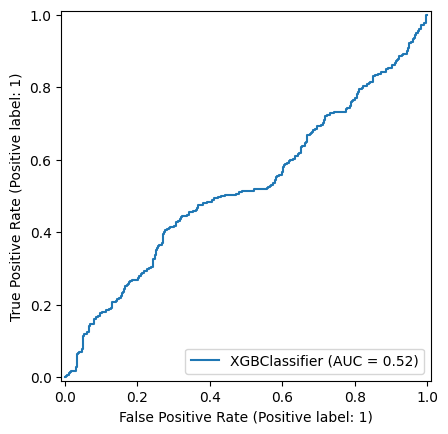

In [80]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    grid_xgb.best_estimator_,
    X_test,
    y_test
)

plt.show()

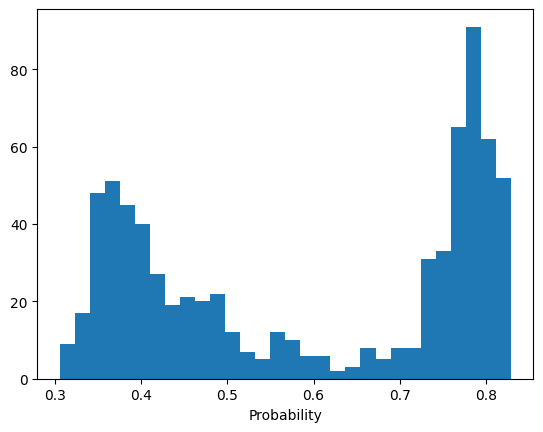

In [81]:
probs = grid_xgb.best_estimator_.predict_proba(X_test)[:,1]

plt.hist(probs, bins=30)

plt.xlabel("Probability")

plt.show()

In [82]:
preds = model.predict(X_test)

probs = model.predict_proba(X_test)[:,1]

print(roc_auc_score(y_test, probs))

0.5232463968084947


In [83]:
joblib.dump(
    grid_xgb.best_estimator_,
    "best_xgboost_10day.pkl"
)

['best_xgboost_10day.pkl']